# 05 Predictor Agreement

Question: Do predictors agree more than annotations do?

This notebook summarizes pairwise agreement between human-proteome predictor outputs and compares that agreement with the experimental annotation-agreement estimates from the annotation ceiling analysis.

## Method

Goal: compare whether trained disorder predictors agree more strongly with each other than the experimental annotation sources behind the corresponding UdonPred dataset-specific models.

This is not an accuracy benchmark against a single ground truth. It is a diagnostic comparison between two agreement levels:

1. Predictor agreement on the human proteome
2. Annotation agreement on overlapping experimentally annotated proteins/residues

The predictor comparison uses matched residues from the same human proteome proteins. For every predictor pair, the script reports residue-level Spearman/Pearson correlation, protein-mean Spearman/Pearson correlation, and z-score MAE. CheZOD, pLDDT, and ADOPT are negated before comparison because their native direction is lower = more disorder.

The annotation comparison joins each UdonPred predictor pair to the matching annotation-ceiling pair. Annotation values come from the original experimental label datasets and are computed only on proteins/residues that overlap between those datasets, not on the human proteome predictions.

The main diagnostic is the difference between predictor Spearman and annotation Spearman. Positive values mean the trained predictors agree more strongly on the human proteome than the underlying experimental annotations agree on their overlapping labeled data. This should be interpreted as model-output convergence, not as proof that the models are better than the annotations.

In [ ]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"
OUTPUT_DIR = RESULTS / "compare_predictors_with_seth_iupred3_adopt_metapredict_punch2Light_disoflag_disorderunetlm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pairwise_csv = OUTPUT_DIR / "pairwise_agreement.csv"
contested_csv = OUTPUT_DIR / "contested_regions.csv"

predictor_args = [
    "trizod=results/human_proteome/UdonPred/trizod",
    "chezod=results/human_proteome/UdonPred/chezod",
    "softdis=results/human_proteome/UdonPred/softdis",
    "pdbflex=results/human_proteome/UdonPred/pdbflex",
    "atlas=results/human_proteome/UdonPred/atlas",
    "plddt=results/human_proteome/UdonPred/plddt",
    "disprot=results/human_proteome/UdonPred/disprot",
    "SETH=results/human_proteome/SETH/seth_human_proteome.caid",
    "IUPred3=results/human_proteome/IUPred3",
    "ADOPT=results/human_proteome/ADOPT",
    "metapredict=results/human_proteome/metapredict/metapredict_human_proteome.caid",
    "PUNCH2_light=results/human_proteome/punch2_light/disorder",
    "DisoFLAG=results/human_proteome/DisoFLAG/caid",
    "DisorderUnetLM=results/human_proteome/DisorderUnetLM/disorder",
]

if pairwise_csv.exists() and contested_csv.exists():
    print("Predictor comparison results already exist, skipping computation.")
else:
    print("Running predictor comparison...")
    cmd = [sys.executable, str(ROOT / "scripts" / "compare_predictors.py")]
    for value in predictor_args:
        cmd.extend(["--predictor", value])
    cmd.extend(["--output-dir", str(OUTPUT_DIR)])
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    result.check_returncode()

pairwise = pd.read_csv(pairwise_csv)
contested_regions = pd.read_csv(contested_csv)

pairwise.head()

Running predictor comparison...
Loaded SETH: 20659 proteins from results/human_proteome/SETH/seth_human_proteome.caid
Loaded IUPred3: 20659 proteins from results/human_proteome/IUPred3
Loaded ADOPT: 20659 proteins from results/human_proteome/ADOPT
Loaded metapredict: 20659 proteins from results/human_proteome/metapredict/metapredict_human_proteome.caid
Loaded PUNCH2_light: 20077 proteins from results/human_proteome/punch2_light/disorder
Loaded DisoFLAG: 20195 proteins from results/human_proteome/DisoFLAG/caid
Loaded DisorderUnetLM: 20659 proteins from results/human_proteome/DisorderUnetLM/disorder
Wrote /Users/kathi/Uni/Master_Semester_3/ProteinPrediction/Protein_Prediction /results/compare_seth_iupred3_adopt_metapredict_punch2Light_disoflag_disorderunetlm/pairwise_agreement.csv
Wrote /Users/kathi/Uni/Master_Semester_3/ProteinPrediction/Protein_Prediction /results/compare_seth_iupred3_adopt_metapredict_punch2Light_disoflag_disorderunetlm/contested_regions.csv

Loaded SETH: 20659 protei

,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
0,ADOPT,DisoFLAG,20195,9387303,0.698514,0.708721,0.574584,0.748291,0.698079,0.552899
1,ADOPT,DisorderUnetLM,20659,9861047,0.721924,0.629393,0.645205,0.740520,0.733112,0.527358
2,ADOPT,IUPred3,20659,9861047,0.637572,0.712196,0.600289,0.704414,0.741337,0.539165
3,ADOPT,PUNCH2_light,20077,9376709,0.802041,0.863447,0.389959,0.910071,0.922457,0.281449
4,ADOPT,SETH,20659,9861047,0.808299,0.875295,0.381239,0.933621,0.948784,0.238737


## Predictor-Predictor Agreement

Residue-level correlation asks whether predictors rank individual residues similarly. Protein-level correlation asks whether they agree on which proteins are globally more disorder-prone.

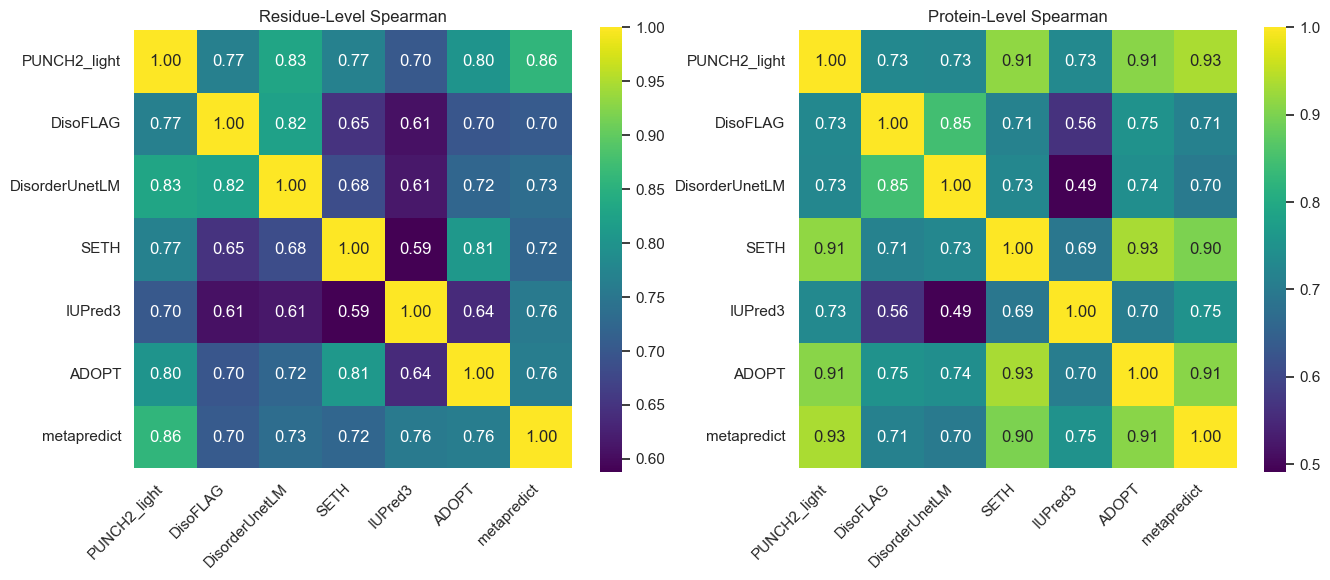

,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
19,PUNCH2_light,metapredict,20077,9987102,0.857652,0.903063,0.278400,0.934630,0.914958,0.247728
12,DisorderUnetLM,PUNCH2_light,20077,9987102,0.830041,0.648831,0.594104,0.727258,0.694059,0.550167
6,DisoFLAG,DisorderUnetLM,20195,9997764,0.822510,0.769733,0.442100,0.845826,0.849864,0.381364
4,ADOPT,SETH,20659,9861047,0.808299,0.875295,0.381239,0.933621,0.948784,0.238737
3,ADOPT,PUNCH2_light,20077,9376709,0.802041,0.863447,0.389959,0.910071,0.922457,0.281449
18,PUNCH2_light,SETH,20077,9987102,0.767308,0.853498,0.376843,0.914613,0.927176,0.272972
8,DisoFLAG,PUNCH2_light,20077,9987102,0.765948,0.717186,0.495263,0.729198,0.682161,0.556243
5,ADOPT,metapredict,20659,9861047,0.761422,0.865045,0.396122,0.908997,0.933275,0.268760
17,IUPred3,metapredict,20659,11456702,0.755719,0.767392,0.515712,0.748133,0.746913,0.503117
14,DisorderUnetLM,metapredict,20659,11456702,0.734336,0.610324,0.631481,0.699779,0.684464,0.570790


In [17]:
predictor_order = [
    name
    for name in ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot", "PUNCH2_light", "DisoFLAG", "DisorderUnetLM", "SETH", "IUPred3", "ADOPT", "metapredict"]
    if name in set(pairwise["predictor_a"]) | set(pairwise["predictor_b"])
]

def pair_matrix(value_column):
    matrix = pd.DataFrame(np.nan, index=predictor_order, columns=predictor_order)
    for predictor in predictor_order:
        matrix.loc[predictor, predictor] = 1.0
    for row in pairwise.itertuples(index=False):
        matrix.loc[row.predictor_a, row.predictor_b] = getattr(row, value_column)
        matrix.loc[row.predictor_b, row.predictor_a] = getattr(row, value_column)
    return matrix

residue_spearman_matrix = pair_matrix("residue_spearman")
protein_spearman_matrix = pair_matrix("protein_spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    residue_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.nanmin(residue_spearman_matrix.values),
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Residue-Level Spearman")
sns.heatmap(
    protein_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.nanmin(protein_spearman_matrix.values),
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Protein-Level Spearman")
# Rotate x tick labels so long labels are visible
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
# Increase margins to give room for rotated labels
fig.subplots_adjust(bottom=0.22, left=0.18)
fig.savefig(OUTPUT_DIR / "predictor_spearman_heatmaps.png", dpi=210, bbox_inches='tight', pad_inches=0.05)
plt.show()

pairwise.sort_values("residue_spearman", ascending=False)

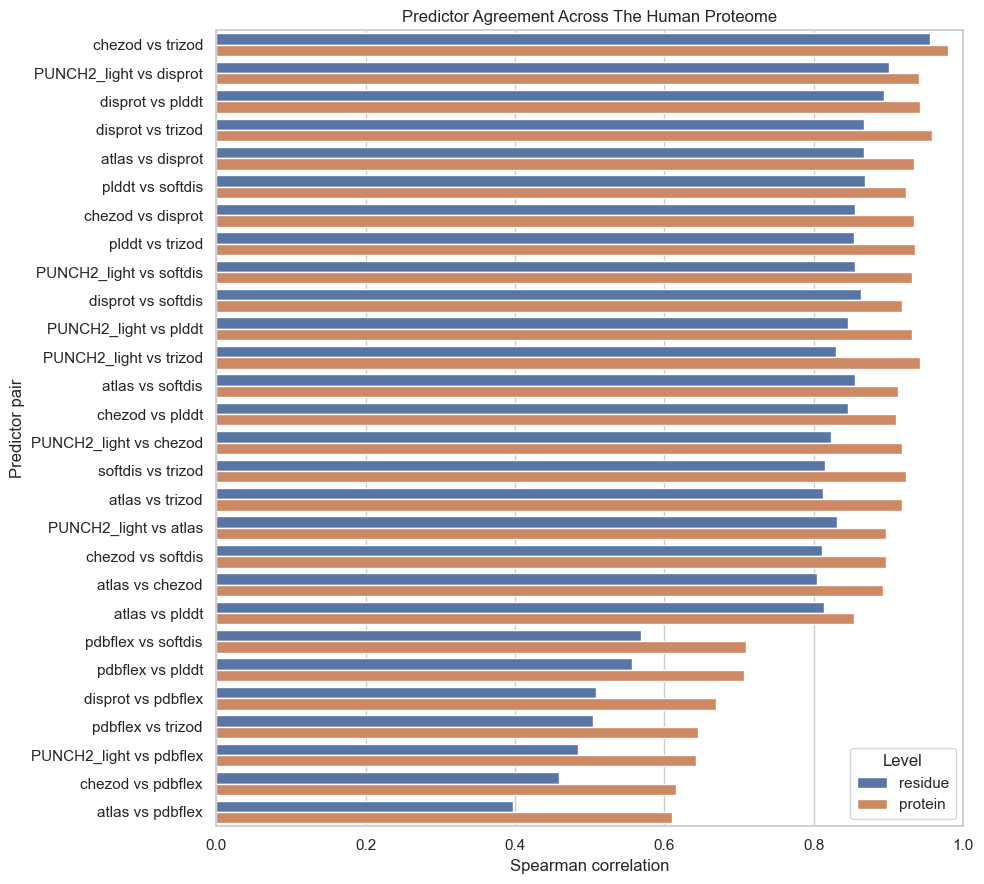

In [3]:
agreement_long = pairwise.melt(
    id_vars=["predictor_a", "predictor_b", "common_proteins", "matched_residues"],
    value_vars=["residue_spearman", "protein_spearman"],
    var_name="level",
    value_name="spearman",
)
agreement_long["pair"] = agreement_long["predictor_a"] + " vs " + agreement_long["predictor_b"]
agreement_long["level"] = agreement_long["level"].str.replace("_spearman", "", regex=False)

pair_order = (
    agreement_long.groupby("pair")["spearman"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
plot_data = agreement_long.copy()

plt.figure(figsize=(10, 9))
sns.barplot(data=plot_data, x="spearman", y="pair", hue="level", order=pair_order)
plt.xlabel("Spearman correlation")
plt.ylabel("Predictor pair")
plt.title("Predictor Agreement Across The Human Proteome")
plt.xlim(0, 1)
plt.legend(title="Level", loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_pairwise_spearman_bars.png", dpi=200)
plt.show()


## Predictor Agreement vs Annotation Agreement

The direct comparison to experimental annotation agreement is restricted to the seven UdonPred dataset-specific models. External predictors are kept in the predictor-agreement analysis, but they do not have a one-to-one annotation source in this project setup.

The annotation agreement values are reused from the experimental ceiling analysis. Positive gaps mean that two trained predictors agree more strongly on the human proteome than the corresponding experimental annotations agree on their overlapping labeled residues or proteins.

Important distinction: the predictor side and the annotation side are not computed on the same residues. Predictor agreement uses human-proteome model outputs. Annotation agreement uses only the experimental overlap between the two underlying label datasets. The comparison is therefore a ceiling/context diagnostic, not a direct accuracy test.

In [4]:
ANNOTATION_CEILING_CSV = RESULTS / "annotation_ceiling" / "annotation_ceiling_summary.csv"
ANNOTATION_CEILING_MMSEQS_CSV = RESULTS / "annotation_ceiling_mmseqs" / "annotation_ceiling_summary.csv"
MMSEQS_MIN_IDENTITY = 90.0
UDONPRED_DATASETS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]

# Annotation-ceiling files summarize how the original experimental label sources
# agree with each other on their overlapping proteins/residues.
# These are separate from the human-proteome prediction outputs below.
annotation_ceiling = pd.read_csv(ANNOTATION_CEILING_CSV)
annotation_ceiling_mmseqs_raw = pd.read_csv(ANNOTATION_CEILING_MMSEQS_CSV)

# MMseqs is kept as a sensitivity analysis: it increases annotation overlap by
# allowing highly similar sequence matches instead of only exact overlaps.
annotation_ceiling_mmseqs = annotation_ceiling_mmseqs_raw[
    (annotation_ceiling_mmseqs_raw["match_mode"] == "mmseqs")
    & (annotation_ceiling_mmseqs_raw["min_identity"] == MMSEQS_MIN_IDENTITY)
].copy()

# Use an order-independent key so "trizod vs chezod" and "chezod vs trizod"
# map to the same predictor/annotation pair.
def normalized_pair_key(left, right):
    return "__".join(sorted([str(left).lower(), str(right).lower()]))

def build_annotation_pair_summary(annotation_frame, column_prefix="annotation"):
    # Collapse the long annotation-ceiling table to one row per dataset pair.
    # Keep both agreement values and overlap counts because small overlaps make
    # Spearman estimates less stable.
    annotation_frame = annotation_frame.copy()
    annotation_frame["pair_key"] = [
        normalized_pair_key(left, right)
        for left, right in zip(annotation_frame["dataset_a"], annotation_frame["dataset_b"])
    ]
    counts = (
        annotation_frame.sort_values(["pair_key", "metric"])
        .groupby("pair_key", as_index=False)
        .agg(
            annotation_dataset_a=("dataset_a", "first"),
            annotation_dataset_b=("dataset_b", "first"),
            annotation_match_mode=("match_mode", "first"),
            n_annotation_proteins=("n_proteins_overlap", "max"),
            n_annotation_residues=("n_residues_compared", "max"),
        )
    )
    value_frame = annotation_frame[annotation_frame["metric"].isin(["spearman", "protein_spearman"])]
    values = (
        value_frame.pivot_table(index="pair_key", columns="metric", values="value", aggfunc="first")
        .reset_index()
    )
    if "spearman" not in values.columns:
        values["spearman"] = np.nan
    if "protein_spearman" not in values.columns:
        values["protein_spearman"] = np.nan
    values = values.rename(
        columns={
            "spearman": f"{column_prefix}_residue_spearman",
            "protein_spearman": f"{column_prefix}_protein_spearman",
        }
    )
    return counts.merge(values, on="pair_key", how="left")

# Only UdonPred dataset-specific models have a direct underlying annotation
# source in this project, so external predictors are excluded from this join.
udon_pairwise = pairwise[
    pairwise["predictor_a"].str.lower().isin(UDONPRED_DATASETS)
    & pairwise["predictor_b"].str.lower().isin(UDONPRED_DATASETS)
].copy()
udon_pairwise["pair_key"] = [
    normalized_pair_key(left, right)
    for left, right in zip(udon_pairwise["predictor_a"], udon_pairwise["predictor_b"])
]
udon_pairwise["pair"] = udon_pairwise["predictor_a"] + " vs " + udon_pairwise["predictor_b"]

annotation_pair_summary = build_annotation_pair_summary(annotation_ceiling, "annotation")
annotation_pair_summary_mmseqs = build_annotation_pair_summary(annotation_ceiling_mmseqs, "mmseqs_annotation")

# Join each predictor pair to the corresponding experimental annotation pair.
# Predictor agreement: model outputs on the human proteome.
# Annotation agreement: original experimental labels on dataset overlap.
udon_predictor_vs_annotation = udon_pairwise.merge(
    annotation_pair_summary,
    on="pair_key",
    how="left",
)
udon_predictor_vs_annotation_sensitivity = udon_pairwise.merge(
    annotation_pair_summary_mmseqs,
    on="pair_key",
    how="left",
)

# Agreement gap quantifies whether model-output agreement exceeds the
# experimental annotation baseline. Positive gap = stronger predictor
# convergence than annotation agreement. It is not an accuracy claim.
udon_predictor_vs_annotation["residue_gap"] = (
    udon_predictor_vs_annotation["residue_spearman"]
    - udon_predictor_vs_annotation["annotation_residue_spearman"]
)
udon_predictor_vs_annotation["protein_gap"] = (
    udon_predictor_vs_annotation["protein_spearman"]
    - udon_predictor_vs_annotation["annotation_protein_spearman"]
)
udon_predictor_vs_annotation_sensitivity["residue_gap"] = (
    udon_predictor_vs_annotation_sensitivity["residue_spearman"]
    - udon_predictor_vs_annotation_sensitivity["mmseqs_annotation_residue_spearman"]
)
udon_predictor_vs_annotation_sensitivity["protein_gap"] = (
    udon_predictor_vs_annotation_sensitivity["protein_spearman"]
    - udon_predictor_vs_annotation_sensitivity["mmseqs_annotation_protein_spearman"]
)

# Flag annotation pairs with little or no experimental overlap so their gaps
# can be interpreted cautiously in tables and plots.
udon_predictor_vs_annotation["annotation_overlap_confidence"] = np.select(
    [
        udon_predictor_vs_annotation["n_annotation_residues"].fillna(0) == 0,
        (udon_predictor_vs_annotation["n_annotation_residues"].fillna(0) < 100)
        | (udon_predictor_vs_annotation["n_annotation_proteins"].fillna(0) < 3),
    ],
    ["no overlap", "low overlap"],
    default="usable overlap",
)
udon_predictor_vs_annotation_sensitivity["annotation_overlap_confidence"] = np.select(
    [
        udon_predictor_vs_annotation_sensitivity["n_annotation_residues"].fillna(0) == 0,
        (udon_predictor_vs_annotation_sensitivity["n_annotation_residues"].fillna(0) < 100)
        | (udon_predictor_vs_annotation_sensitivity["n_annotation_proteins"].fillna(0) < 3),
    ],
    ["no overlap", "low overlap"],
    default="usable overlap",
)

comparison_columns = [
    "pair",
    "common_proteins",
    "matched_residues",
    "residue_spearman",
    "annotation_residue_spearman",
    "residue_gap",
    "protein_spearman",
    "annotation_protein_spearman",
    "protein_gap",
    "n_annotation_proteins",
    "n_annotation_residues",
    "annotation_overlap_confidence",
]
udon_predictor_vs_annotation[comparison_columns].sort_values("residue_gap", ascending=False)


,pair,common_proteins,matched_residues,residue_spearman,annotation_residue_spearman,residue_gap,protein_spearman,annotation_protein_spearman,protein_gap,n_annotation_proteins,n_annotation_residues,annotation_overlap_confidence
11,disprot vs pdbflex,20659,11456702,0.507872,-0.151455,0.659327,0.669268,0.464286,0.204982,7,2335,usable overlap
0,atlas vs chezod,20659,11456702,0.804006,0.220828,0.583178,0.892633,NaN,NaN,2,372,low overlap
15,pdbflex vs plddt,20659,11456702,0.557118,0.011500,0.545618,0.705861,0.485714,0.220147,6,1412,usable overlap
4,atlas vs softdis,20659,11456702,0.855393,0.315038,0.540355,0.912408,0.487745,0.424663,17,1558,usable overlap
3,atlas vs plddt,20659,11456702,0.813176,0.295052,0.518124,0.854050,NaN,NaN,2,424,low overlap
16,pdbflex vs softdis,20659,11456702,0.568781,0.077090,0.491691,0.708999,0.040218,0.668781,748,123212,usable overlap
9,chezod vs softdis,20659,11456702,0.811431,0.332540,0.478891,0.896202,NaN,NaN,1,72,low overlap
10,chezod vs trizod,20659,11456702,0.955227,0.481978,0.473249,0.980046,NaN,NaN,1,138,low overlap
13,disprot vs softdis,20659,11456702,0.863369,0.488921,0.374448,0.917692,0.761905,0.155787,8,2642,usable overlap
19,plddt vs trizod,20659,11456702,0.854218,0.504646,0.349572,0.935306,1.000000,-0.064694,2,283,low overlap


In [5]:
mmseqs_sensitivity_comparison = udon_predictor_vs_annotation[
    [
        "pair_key",
        "pair",
        "residue_spearman",
        "annotation_residue_spearman",
        "residue_gap",
        "protein_spearman",
        "annotation_protein_spearman",
        "protein_gap",
        "n_annotation_proteins",
        "n_annotation_residues",
    ]
].merge(
    udon_predictor_vs_annotation_sensitivity[
        [
            "pair_key",
            "mmseqs_annotation_residue_spearman",
            "mmseqs_annotation_protein_spearman",
            "residue_gap",
            "protein_gap",
            "n_annotation_proteins",
            "n_annotation_residues",
        ]
    ].rename(
        columns={
            "residue_gap": "mmseqs_residue_gap",
            "protein_gap": "mmseqs_protein_gap",
            "n_annotation_proteins": "mmseqs_n_annotation_proteins",
            "n_annotation_residues": "mmseqs_n_annotation_residues",
        }
    ),
    on="pair_key",
    how="left",
)
mmseqs_sensitivity_comparison["mmseqs_min_identity"] = MMSEQS_MIN_IDENTITY
mmseqs_sensitivity_comparison["annotation_residue_spearman_change"] = (
    mmseqs_sensitivity_comparison["mmseqs_annotation_residue_spearman"]
    - mmseqs_sensitivity_comparison["annotation_residue_spearman"]
)
mmseqs_sensitivity_comparison["annotation_protein_spearman_change"] = (
    mmseqs_sensitivity_comparison["mmseqs_annotation_protein_spearman"]
    - mmseqs_sensitivity_comparison["annotation_protein_spearman"]
)

mmseqs_display_columns = [
    "pair",
    "residue_spearman",
    "annotation_residue_spearman",
    "mmseqs_annotation_residue_spearman",
    "residue_gap",
    "mmseqs_residue_gap",
    "protein_spearman",
    "annotation_protein_spearman",
    "mmseqs_annotation_protein_spearman",
    "protein_gap",
    "mmseqs_protein_gap",
    "n_annotation_proteins",
    "n_annotation_residues",
    "mmseqs_n_annotation_proteins",
    "mmseqs_n_annotation_residues",
    "annotation_residue_spearman_change",
    "annotation_protein_spearman_change",
]
mmseqs_sensitivity_comparison[mmseqs_display_columns].sort_values(
    "annotation_residue_spearman_change",
    ascending=False,
)


,pair,residue_spearman,annotation_residue_spearman,mmseqs_annotation_residue_spearman,residue_gap,mmseqs_residue_gap,protein_spearman,annotation_protein_spearman,mmseqs_annotation_protein_spearman,protein_gap,mmseqs_protein_gap,n_annotation_proteins,n_annotation_residues,mmseqs_n_annotation_proteins,mmseqs_n_annotation_residues,annotation_residue_spearman_change,annotation_protein_spearman_change
10,chezod vs trizod,0.955227,0.481978,0.940091,0.473249,0.015136,0.980046,NaN,NaN,NaN,NaN,1,138,2.0,348.0,0.458113,NaN
0,atlas vs chezod,0.804006,0.220828,0.623305,0.583178,0.180701,0.892633,NaN,NaN,NaN,NaN,2,372,2.0,249.0,0.402477,NaN
15,pdbflex vs plddt,0.557118,0.011500,0.283949,0.545618,0.273169,0.705861,0.485714,NaN,0.220147,NaN,6,1412,51.0,9663.0,0.272449,NaN
2,atlas vs pdbflex,0.397378,0.111006,0.290880,0.286372,0.106498,0.610370,0.144259,NaN,0.466111,NaN,25,2587,46.0,6835.0,0.179874,NaN
4,atlas vs softdis,0.855393,0.315038,0.453333,0.540355,0.402060,0.912408,0.487745,NaN,0.424663,NaN,17,1558,51.0,7216.0,0.138295,NaN
16,pdbflex vs softdis,0.568781,0.077090,0.139716,0.491691,0.429065,0.708999,0.040218,NaN,0.668781,NaN,748,123212,1173.0,197023.0,0.062626,NaN
19,plddt vs trizod,0.854218,0.504646,0.499411,0.349572,0.354807,0.935306,1.000000,NaN,-0.064694,NaN,2,283,8.0,1091.0,-0.005235,NaN
17,pdbflex vs trizod,0.503730,0.174514,0.144694,0.329216,0.359036,0.645033,0.400000,NaN,0.245033,NaN,4,525,43.0,5096.0,-0.029820,NaN
9,chezod vs softdis,0.811431,0.332540,0.300704,0.478891,0.510727,0.896202,NaN,NaN,NaN,NaN,1,72,9.0,881.0,-0.031836,NaN
11,disprot vs pdbflex,0.507872,-0.151455,-0.187034,0.659327,0.694906,0.669268,0.464286,NaN,0.204982,NaN,7,2335,29.0,9734.0,-0.035579,NaN


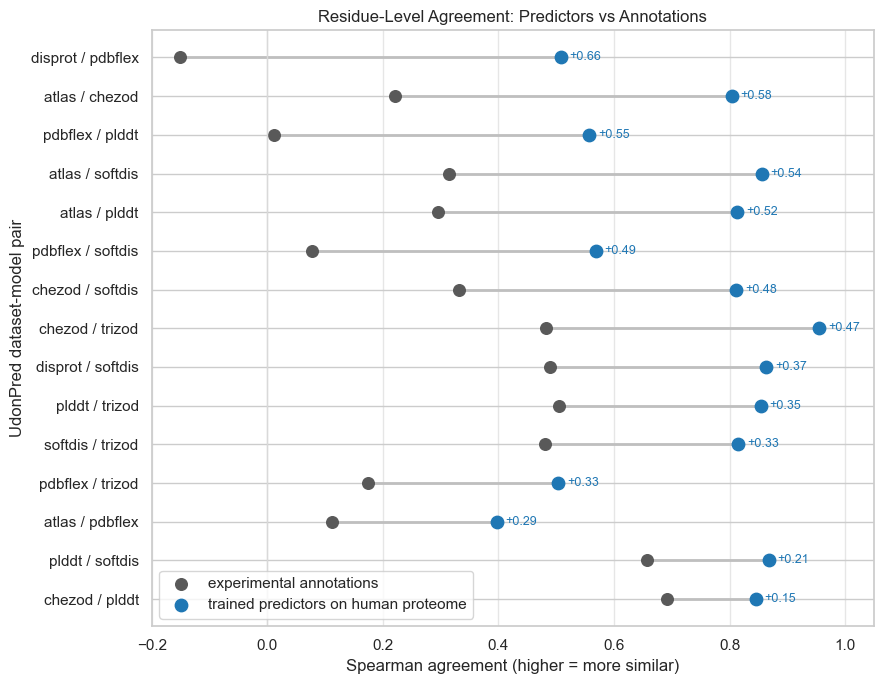

In [6]:
plot_data = udon_predictor_vs_annotation.dropna(
    subset=["annotation_residue_spearman", "residue_spearman"]
).copy()
plot_data = plot_data.sort_values("residue_gap", ascending=False).reset_index(drop=True)
plot_data["pair_label"] = plot_data["pair"].str.replace(" vs ", " / ", regex=False)
plot_data["y"] = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 7))
for row in plot_data.itertuples(index=False):
    ax.plot(
        [row.annotation_residue_spearman, row.residue_spearman],
        [row.y, row.y],
        color="0.75",
        linewidth=2,
        zorder=1,
    )

ax.scatter(
    plot_data["annotation_residue_spearman"],
    plot_data["y"],
    color="0.35",
    s=70,
    label="experimental annotations",
    zorder=2,
)
ax.scatter(
    plot_data["residue_spearman"],
    plot_data["y"],
    color="tab:blue",
    s=80,
    label="trained predictors on human proteome",
    zorder=3,
)

for row in plot_data.itertuples(index=False):
    ax.text(
        max(row.annotation_residue_spearman, row.residue_spearman) + 0.015,
        row.y,
        f"{row.residue_gap:+.2f}",
        va="center",
        fontsize=9,
        color="tab:blue" if row.residue_gap >= 0 else "tab:orange",
    )

ax.set_yticks(plot_data["y"])
ax.set_yticklabels(plot_data["pair_label"])
ax.invert_yaxis()
ax.set_xlabel("Spearman agreement (higher = more similar)")
ax.set_ylabel("UdonPred dataset-model pair")
ax.set_title("Residue-Level Agreement: Predictors vs Annotations")
ax.set_xlim(-0.2, 1.05)
ax.axvline(0, color="0.85", linewidth=1)
ax.grid(axis="x", color="0.9")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_vs_annotation_residue_scatter.png", dpi=200)
plt.show()


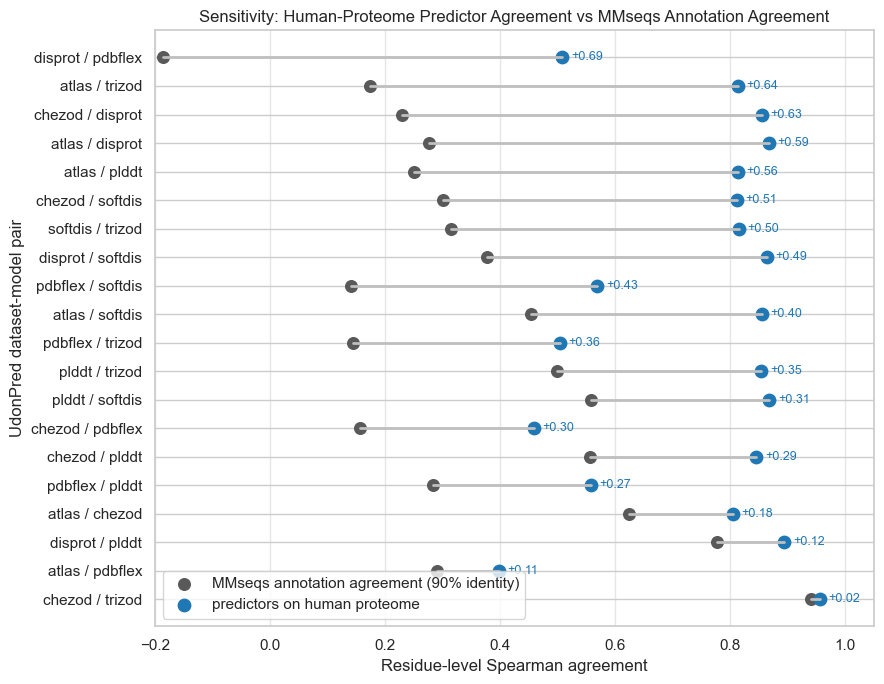

In [7]:
plot_data = mmseqs_sensitivity_comparison.dropna(
    subset=["mmseqs_annotation_residue_spearman", "residue_spearman"]
).copy()

plot_data = plot_data.sort_values("mmseqs_residue_gap", ascending=False).reset_index(drop=True)
plot_data["pair_label"] = plot_data["pair"].str.replace(" vs ", " / ", regex=False)
plot_data["y"] = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 7))

for row in plot_data.itertuples(index=False):
    ax.plot(
        [row.mmseqs_annotation_residue_spearman, row.residue_spearman],
        [row.y, row.y],
        color="0.75",
        linewidth=2,
    )

ax.scatter(
    plot_data["mmseqs_annotation_residue_spearman"],
    plot_data["y"],
    color="0.35",
    s=70,
    label=f"MMseqs annotation agreement ({MMSEQS_MIN_IDENTITY:.0f}% identity)",
)
ax.scatter(
    plot_data["residue_spearman"],
    plot_data["y"],
    color="tab:blue",
    s=80,
    label="predictors on human proteome",
)

for row in plot_data.itertuples(index=False):
    ax.text(
        max(row.mmseqs_annotation_residue_spearman, row.residue_spearman) + 0.015,
        row.y,
        f"{row.mmseqs_residue_gap:+.2f}",
        va="center",
        fontsize=9,
        color="tab:blue" if row.mmseqs_residue_gap >= 0 else "tab:orange",
    )

ax.set_yticks(plot_data["y"])
ax.set_yticklabels(plot_data["pair_label"])
ax.invert_yaxis()
ax.set_xlabel("Residue-level Spearman agreement")
ax.set_ylabel("UdonPred dataset-model pair")
ax.set_title("Sensitivity: Human-Proteome Predictor Agreement vs MMseqs Annotation Agreement")
ax.set_xlim(-0.2, 1.05)
ax.grid(axis="x", color="0.9")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_vs_mmseqs_annotation_residue_agreement.png", dpi=200)
plt.show()


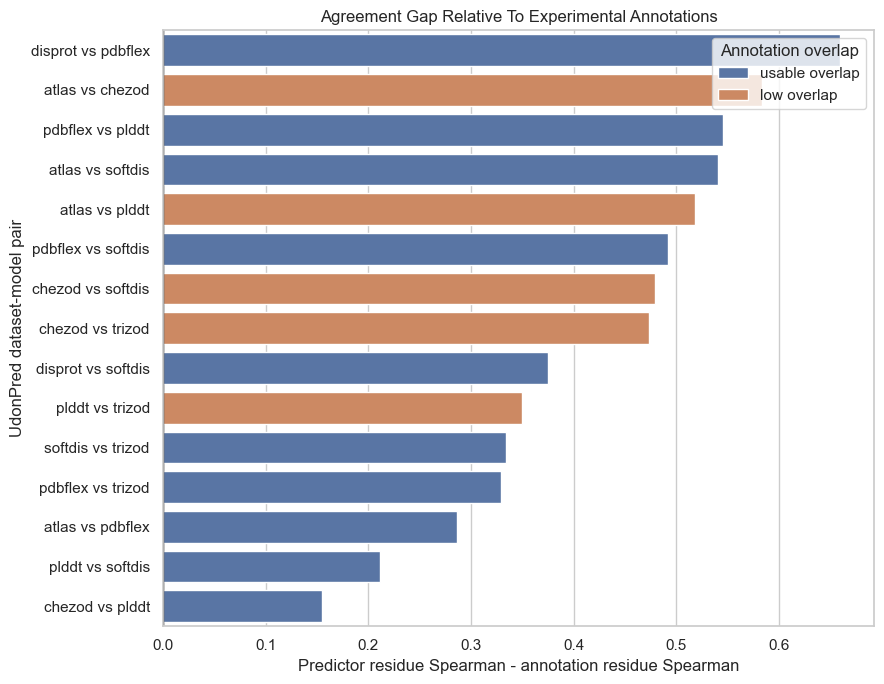

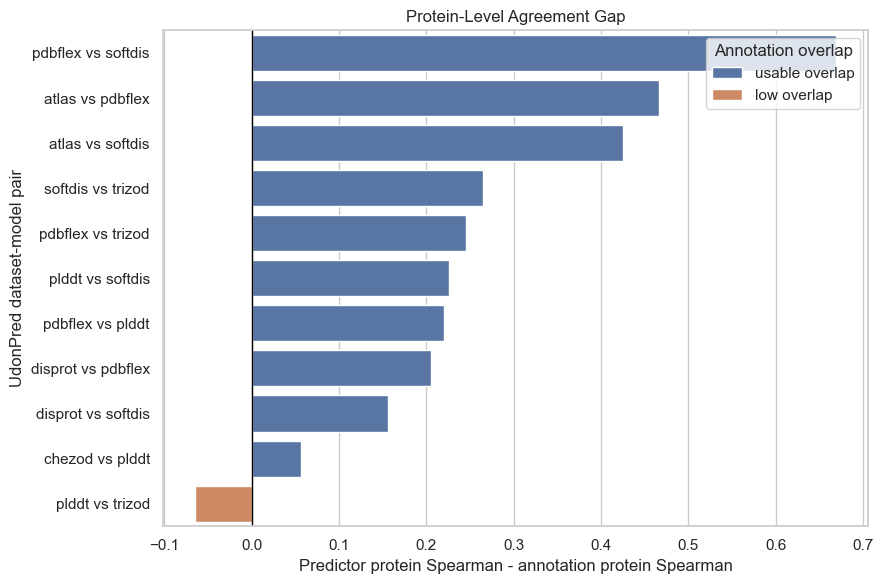

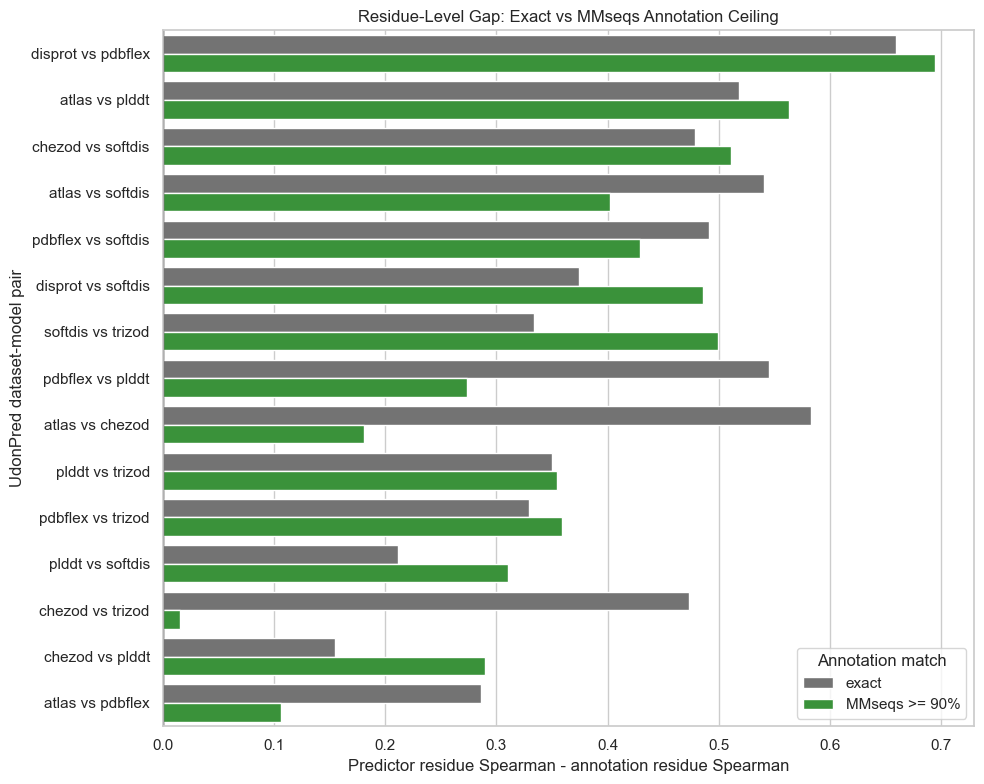

No MMseqs protein-level annotation gaps available yet. Regenerate results/annotation_ceiling_mmseqs with the updated estimate_annotation_ceiling.py to create the protein exact-vs-MMseqs gap plot.


In [8]:
gap_data = udon_predictor_vs_annotation.dropna(subset=["residue_gap"]).sort_values(
    "residue_gap",
    ascending=False,
)

plt.figure(figsize=(9, 7))
sns.barplot(
    data=gap_data,
    x="residue_gap",
    y="pair",
    hue="annotation_overlap_confidence",
    order=gap_data["pair"].tolist(),
    dodge=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predictor residue Spearman - annotation residue Spearman")
plt.ylabel("UdonPred dataset-model pair")
plt.title("Agreement Gap Relative To Experimental Annotations")
plt.legend(title="Annotation overlap", loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_annotation_residue_gap.png", dpi=200)
plt.show()

protein_gap_data = udon_predictor_vs_annotation.dropna(subset=["protein_gap"]).sort_values(
    "protein_gap",
    ascending=False,
)
plt.figure(figsize=(9, 6))
sns.barplot(
    data=protein_gap_data,
    x="protein_gap",
    y="pair",
    hue="annotation_overlap_confidence",
    order=protein_gap_data["pair"].tolist(),
    dodge=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predictor protein Spearman - annotation protein Spearman")
plt.ylabel("UdonPred dataset-model pair")
plt.title("Protein-Level Agreement Gap")
plt.legend(title="Annotation overlap", loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_annotation_protein_gap.png", dpi=200)
plt.show()

exact_gap_frame = udon_predictor_vs_annotation[
    ["pair", "residue_gap", "protein_gap"]
].assign(annotation_match="exact")
mmseqs_gap_frame = udon_predictor_vs_annotation_sensitivity[
    ["pair", "residue_gap", "protein_gap"]
].assign(annotation_match=f"MMseqs >= {MMSEQS_MIN_IDENTITY:.0f}%")
gap_comparison = pd.concat([exact_gap_frame, mmseqs_gap_frame], ignore_index=True)

def keep_pairs_with_exact_and_mmseqs(frame, value_column):
    available = frame.dropna(subset=[value_column]).copy()
    complete_pairs = (
        available.groupby("pair")["annotation_match"]
        .nunique()
        .loc[lambda counts: counts == 2]
        .index
    )
    return available[available["pair"].isin(complete_pairs)].copy()

residue_gap_comparison = keep_pairs_with_exact_and_mmseqs(gap_comparison, "residue_gap")
residue_pair_order = (
    residue_gap_comparison.groupby("pair")["residue_gap"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
plt.figure(figsize=(10, 8))
sns.barplot(
    data=residue_gap_comparison,
    x="residue_gap",
    y="pair",
    hue="annotation_match",
    order=residue_pair_order,
    dodge=True,
    palette={"exact": "0.45", f"MMseqs >= {MMSEQS_MIN_IDENTITY:.0f}%": "tab:green"},
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Predictor residue Spearman - annotation residue Spearman")
plt.ylabel("UdonPred dataset-model pair")
plt.title("Residue-Level Gap: Exact vs MMseqs Annotation Ceiling")
plt.legend(title="Annotation match")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "udon_predictor_annotation_residue_gap_exact_vs_mmseqs.png", dpi=200)
plt.show()

protein_gap_comparison = keep_pairs_with_exact_and_mmseqs(gap_comparison, "protein_gap")
protein_pair_order = (
    protein_gap_comparison.groupby("pair")["protein_gap"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
if protein_gap_comparison["annotation_match"].nunique() > 1:
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=protein_gap_comparison,
        x="protein_gap",
        y="pair",
        hue="annotation_match",
        order=protein_pair_order,
        dodge=True,
        palette={"exact": "0.45", f"MMseqs >= {MMSEQS_MIN_IDENTITY:.0f}%": "tab:green"},
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("Predictor protein Spearman - annotation protein Spearman")
    plt.ylabel("UdonPred dataset-model pair")
    plt.title("Protein-Level Gap: Exact vs MMseqs Annotation Ceiling")
    plt.legend(title="Annotation match")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "udon_predictor_annotation_protein_gap_exact_vs_mmseqs.png", dpi=200)
    plt.show()
else:
    print(
        "No MMseqs protein-level annotation gaps available yet. "
        "Regenerate results/annotation_ceiling_mmseqs with the updated estimate_annotation_ceiling.py "
        "to create the protein exact-vs-MMseqs gap plot."
    )


## External Predictors

The external methods remain useful as reference predictors on the same human-proteome panel. They are not assigned an annotation-ceiling baseline here because their training data do not map cleanly to one of the seven UdonPred annotation sources.


In [9]:
external_predictors = sorted(
    (set(pairwise["predictor_a"]) | set(pairwise["predictor_b"])) - set(UDONPRED_DATASETS)
)
external_pairwise = pairwise[
    pairwise["predictor_a"].isin(external_predictors)
    | pairwise["predictor_b"].isin(external_predictors)
].copy()
external_pairwise["pair"] = external_pairwise["predictor_a"] + " vs " + external_pairwise["predictor_b"]
external_pairwise.sort_values("residue_spearman", ascending=False)[
    ["pair", "common_proteins", "matched_residues", "residue_spearman", "protein_spearman", "residue_zscore_mae"]
]


,pair,common_proteins,matched_residues,residue_spearman,protein_spearman,residue_zscore_mae
40,disprot vs metapredict,20659,11456702,0.836354,0.924590,0.265906
26,SETH vs trizod,20659,11456702,0.834648,0.925336,0.348158
20,SETH vs chezod,20659,11456702,0.830236,0.922232,0.372125
9,ADOPT vs trizod,20659,9861047,0.817652,0.931511,0.373241
1,ADOPT vs SETH,20659,9861047,0.808299,0.933621,0.381239
3,ADOPT vs chezod,20659,9861047,0.803898,0.919019,0.392639
24,SETH vs plddt,20659,11456702,0.789818,0.904977,0.364516
46,metapredict vs plddt,20659,11456702,0.786024,0.914050,0.340356
7,ADOPT vs plddt,20659,9861047,0.785948,0.906197,0.385563
4,ADOPT vs disprot,20659,9861047,0.784306,0.923026,0.378025


### External Predictors vs UdonPred Consensus

To include external predictors without assigning them an artificial annotation baseline, compare each external method to a scale-normalized consensus of the seven UdonPred dataset-specific models. UdonPred models are also compared to a leave-one-out UdonPred consensus to provide context for how close a method is to the shared UdonPred signal.

Consensus = What is the common signal that the seven UdonPred models agree on, on average?

The consensus is built after all predictor outputs are put into the same score direction and z-score normalized. It is not a ground truth label. It is an internal reference signal: the residue-wise average of the normalized UdonPred model outputs.

For UdonPred models, the target model is excluded from its own consensus (leave-one-out). For external predictors, the target is compared to the full seven-model UdonPred consensus because there is no direct annotation-ceiling baseline for those external methods.

In [10]:
import importlib.util
import sys

compare_predictors_spec = importlib.util.spec_from_file_location(
    "compare_predictors_module",
    ROOT / "scripts" / "compare_predictors.py",
)
compare_predictors_module = importlib.util.module_from_spec(compare_predictors_spec)
sys.modules[compare_predictors_spec.name] = compare_predictors_module
compare_predictors_spec.loader.exec_module(compare_predictors_module)

predictor_paths = {}
for value in predictor_args:
    name, relative_path = compare_predictors_module.parse_predictor_argument(value)
    predictor_paths[name] = ROOT / relative_path

# Load all predictor outputs and convert them to a shared direction where
# higher scores consistently mean more disorder-like signal.
negated_predictors = {name.lower() for name in compare_predictors_module.DEFAULT_NEGATED_PREDICTORS}
consensus_predictions = {}
for name, path in predictor_paths.items():
    loaded = compare_predictors_module.load_predictions(path)
    consensus_predictions[name] = compare_predictors_module.maybe_negate_scores(
        loaded,
        name,
        negated_predictors,
    )

# Z-score scaling removes raw scale differences between predictors before
# averaging. The consensus should reflect shared patterns, not score units.
scaled_consensus_predictions = compare_predictors_module.scale_predictions(
    consensus_predictions,
    method="zscore",
)

def compare_to_consensus(target_name, consensus_names, comparison_group):
    # Compare one target predictor to the residue-wise mean of the chosen
    # consensus models on proteins/residues available for all participants.
    target = scaled_consensus_predictions[target_name]
    consensus_sources = [scaled_consensus_predictions[name] for name in consensus_names]
    common_ids = sorted(set(target).intersection(*(set(source) for source in consensus_sources)))

    residue_target = []
    residue_consensus = []
    protein_target = []
    protein_consensus = []

    for protein_id in common_ids:
        records = [source[protein_id] for source in consensus_sources]
        target_record = target[protein_id]
        length = min([len(record.scores) for record in records] + [len(target_record.scores)])
        if length == 0:
            continue
        consensus_matrix = np.vstack([record.scores[:length] for record in records])
        target_scores = target_record.scores[:length]
        mask = np.all(np.isfinite(consensus_matrix), axis=0) & np.isfinite(target_scores)
        if not np.any(mask):
            continue

        # Consensus score for one residue = average normalized score across
        # the selected UdonPred models for that same residue.
        consensus_scores = np.mean(consensus_matrix[:, mask], axis=0)
        target_scores = target_scores[mask]
        residue_consensus.append(consensus_scores)
        residue_target.append(target_scores)
        protein_consensus.append(float(np.mean(consensus_scores)))
        protein_target.append(float(np.mean(target_scores)))

    if residue_target:
        flat_target = np.concatenate(residue_target)
        flat_consensus = np.concatenate(residue_consensus)
    else:
        flat_target = np.asarray([], dtype=np.float64)
        flat_consensus = np.asarray([], dtype=np.float64)

    protein_target = np.asarray(protein_target, dtype=np.float64)
    protein_consensus = np.asarray(protein_consensus, dtype=np.float64)
    return {
        "predictor": target_name,
        "comparison_group": comparison_group,
        "consensus_models": ", ".join(consensus_names),
        "common_proteins": len(common_ids),
        "matched_residues": len(flat_target),
        "residue_spearman_vs_udon_consensus": compare_predictors_module.correlation(
            flat_target,
            flat_consensus,
            "spearman",
        ),
        "protein_spearman_vs_udon_consensus": compare_predictors_module.correlation(
            protein_target,
            protein_consensus,
            "spearman",
        ),
        "residue_zscore_mae_vs_udon_consensus": float(
            np.mean(
                np.abs(
                    compare_predictors_module.zscore(flat_target)
                    - compare_predictors_module.zscore(flat_consensus)
                )
            )
        )
        if len(flat_target)
        else np.nan,
    }

consensus_rows = []
# UdonPred models use leave-one-out consensus so the target model is not part
# of the reference it is evaluated against.
for predictor in UDONPRED_DATASETS:
    leave_one_out_names = [name for name in UDONPRED_DATASETS if name != predictor]
    consensus_rows.append(compare_to_consensus(predictor, leave_one_out_names, "UdonPred leave-one-out"))
# External predictors are compared to the full UdonPred consensus because they
# do not map cleanly to a single underlying annotation source here.
for predictor in external_predictors:
    consensus_rows.append(compare_to_consensus(predictor, UDONPRED_DATASETS, "external predictor"))

predictor_vs_udon_consensus = pd.DataFrame(consensus_rows).sort_values(
    ["comparison_group", "residue_spearman_vs_udon_consensus"],
    ascending=[True, False],
)
predictor_vs_udon_consensus.to_csv(OUTPUT_DIR / "predictor_vs_udonpred_consensus.csv", index=False)
predictor_vs_udon_consensus


,predictor,comparison_group,consensus_models,common_proteins,matched_residues,residue_spearman_vs_udon_consensus,protein_spearman_vs_udon_consensus,residue_zscore_mae_vs_udon_consensus
6,disprot,UdonPred leave-one-out,"trizod, chezod, softdis, pdbflex, atlas, plddt",20659,11456702,0.916665,0.972968,0.246964
5,plddt,UdonPred leave-one-out,"trizod, chezod, softdis, pdbflex, atlas, disprot",20659,11456702,0.912564,0.948811,0.238840
0,trizod,UdonPred leave-one-out,"chezod, softdis, pdbflex, atlas, plddt, disprot",20659,11456702,0.908561,0.972368,0.282791
2,softdis,UdonPred leave-one-out,"trizod, chezod, pdbflex, atlas, plddt, disprot",20659,11456702,0.896455,0.942154,0.290015
1,chezod,UdonPred leave-one-out,"trizod, softdis, pdbflex, atlas, plddt, disprot",20659,11456702,0.881492,0.945509,0.287556
4,atlas,UdonPred leave-one-out,"trizod, chezod, softdis, pdbflex, plddt, disprot",20659,11456702,0.849045,0.920113,0.479149
3,pdbflex,UdonPred leave-one-out,"trizod, chezod, softdis, atlas, plddt, disprot",20659,11456702,0.533109,0.676225,0.800698
9,SETH,external predictor,"trizod, chezod, softdis, pdbflex, atlas, plddt...",20659,11456702,0.816252,0.915609,0.355050
7,ADOPT,external predictor,"trizod, chezod, softdis, pdbflex, atlas, plddt...",20659,9861047,0.815876,0.924379,0.371848
10,metapredict,external predictor,"trizod, chezod, softdis, pdbflex, atlas, plddt...",20659,11456702,0.811448,0.928865,0.340324


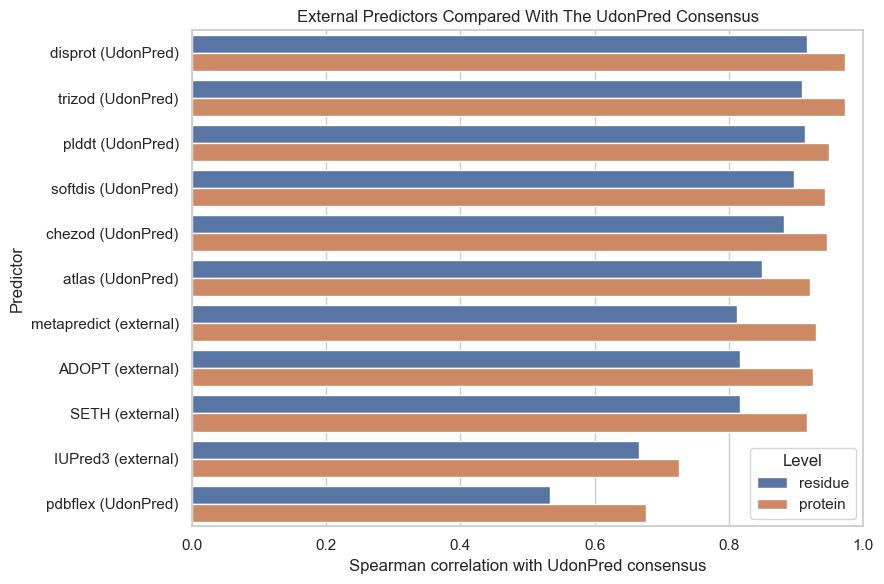

In [11]:
consensus_plot_data = predictor_vs_udon_consensus.melt(
    id_vars=["predictor", "comparison_group", "common_proteins", "matched_residues"],
    value_vars=["residue_spearman_vs_udon_consensus", "protein_spearman_vs_udon_consensus"],
    var_name="level",
    value_name="spearman_vs_consensus",
)
consensus_plot_data["level"] = consensus_plot_data["level"].map(
    {
        "residue_spearman_vs_udon_consensus": "residue",
        "protein_spearman_vs_udon_consensus": "protein",
    }
)
consensus_plot_data["predictor_label"] = np.where(
    consensus_plot_data["comparison_group"] == "external predictor",
    consensus_plot_data["predictor"] + " (external)",
    consensus_plot_data["predictor"] + " (UdonPred)",
)
order = (
    consensus_plot_data.groupby("predictor_label")["spearman_vs_consensus"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=consensus_plot_data,
    x="spearman_vs_consensus",
    y="predictor_label",
    hue="level",
    order=order,
)
plt.xlabel("Spearman correlation with UdonPred consensus")
plt.ylabel("Predictor")
plt.title("External Predictors Compared With The UdonPred Consensus")
plt.xlim(0, 1)
plt.legend(title="Level", loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_vs_udonpred_consensus.png", dpi=200)
plt.show()


## Contested Regions

The contested-region table ranks fixed windows by disagreement after z-score scaling predictor outputs. These regions are candidates for follow-up inspection rather than model-performance errors, because no human-proteome ground truth is assumed here.


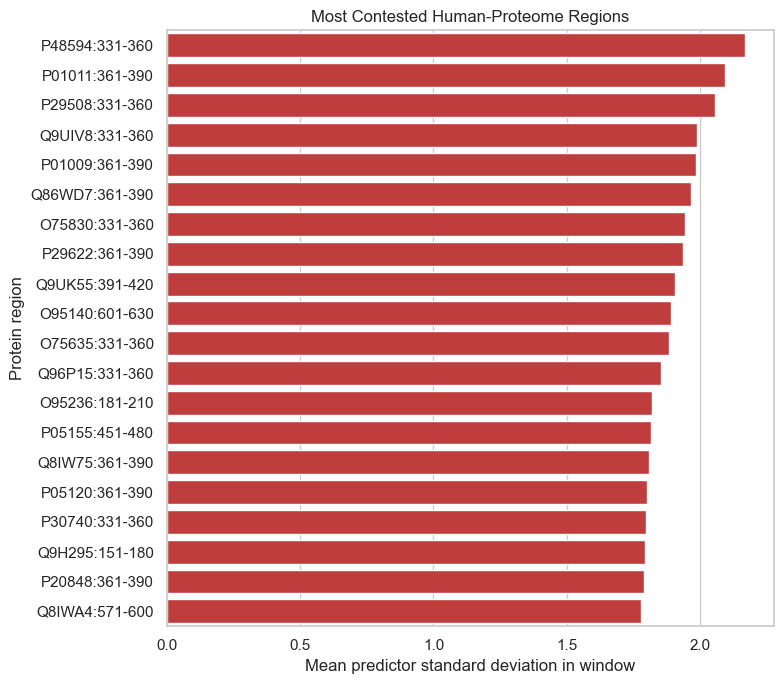

,protein_id,start_residue,end_residue,mean_std,max_std,max_range,max_disagreement_residue,mean_score
0,P48594,331,360,2.17022,3.24599,11.90340,344,0.619233
1,P01011,361,390,2.09489,3.17564,11.58140,373,0.550390
2,P29508,331,360,2.05569,3.34633,12.21770,342,0.733154
3,Q9UIV8,331,360,1.98814,3.18027,11.54750,343,0.570113
4,P01009,361,390,1.98538,3.15559,11.61580,370,0.381772
5,Q86WD7,361,390,1.96706,3.19779,11.80240,366,0.567095
6,O75830,331,360,1.94263,3.13530,11.49660,346,0.472719
7,P29622,361,390,1.93603,3.23225,11.80980,377,0.407750
8,Q9UK55,391,420,1.90606,3.07822,11.36830,396,0.252256
9,O95140,601,630,1.89359,2.38496,9.47962,611,0.778924


In [12]:
contested_display_columns = [
    "protein_id",
    "start_residue",
    "end_residue",
    "mean_std",
    "max_std",
    "max_range",
    "max_disagreement_residue",
    "mean_score",
]
contested_top = contested_regions.sort_values(["mean_std", "max_std"], ascending=False).head(20).copy()
contested_top["region"] = (
    contested_top["protein_id"].astype(str)
    + ":"
    + contested_top["start_residue"].astype(str)
    + "-"
    + contested_top["end_residue"].astype(str)
)

plt.figure(figsize=(8, 7))
sns.barplot(
    data=contested_top,
    x="mean_std",
    y="region",
    order=contested_top["region"].tolist(),
    color="tab:red",
)
plt.xlabel("Mean predictor standard deviation in window")
plt.ylabel("Protein region")
plt.title("Most Contested Human-Proteome Regions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_contested_regions.png", dpi=200)
plt.show()

contested_top[contested_display_columns]
